### Time Travel

In LangGraph, **time travel refers to the ability to revisit and re-execute a graph from a previously saved checkpoint**. This is made possible by its persistence layer, which stores the state of the graph at each super-step during execution.

Time travel is especially useful in scenarios such as:

  - Debugging: Replaying a graph from a specific point to inspect or fix logic.

    - Human-in-the-loop workflows: Allowing users to intervene, modify, or approve mid-execution decisions.

    - Experimentation: Trying alternative paths or decisions from a known state.

    - Fault recovery: Resuming execution after a failure without restarting from scratch.

In [2]:
from langchain_ollama import ChatOllama

# Run this cell to use a local Ollama model instead of ChatBedrockConverse
model = ChatOllama(
    model="llama3.2:latest",
    temperature=0.4,
    num_predict=50,   # equivalent to max_tokens
)

In [3]:
model.invoke("hi")

AIMessage(content='How can I help you today?', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-06-25T01:38:09.1856456Z', 'done': True, 'done_reason': 'stop', 'total_duration': 24496833600, 'load_duration': 17873710300, 'prompt_eval_count': 26, 'prompt_eval_duration': 4552883600, 'eval_count': 8, 'eval_duration': 2022546700, 'logprobs': None, 'model_name': 'llama3.2:latest', 'model_provider': 'ollama'}, id='lc_run--019efc6d-086d-7690-9331-2868f2f64079-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 26, 'output_tokens': 8, 'total_tokens': 34})

C:\Users\siddhanna.janai\AppData\Roaming\Python\Python313\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


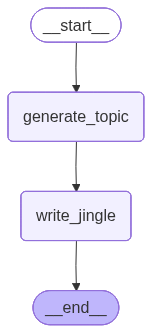

In [4]:
import uuid

from typing_extensions import TypedDict, NotRequired
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from langchain_aws import ChatBedrockConverse



class State(TypedDict):
    topic: NotRequired[str]
    jingle: NotRequired[str]


# Run the ChatOllama cell above OR uncomment the block below to use Bedrock
# model = ChatBedrockConverse(
#     model_id="amazon.nova-lite-v1:0",
#     region_name="us-east-1",
#     temperature=0.4,
#     max_tokens=50
# )



def generate_topic(state: State):
    """LLM call to generate a topic for the jingle"""
    msg = model.invoke("Give me a fun and catchy topic for a jingle")
    return {"topic": msg.content}


def write_jingle(state: State):
    """LLM call to write a jingle based on the topic"""
    msg = model.invoke(f"Write a short, catchy jingle about {state['topic']}")
    return {"jingle": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_topic", generate_topic)
workflow.add_node("write_jingle", write_jingle)

# Add edges to connect nodes
workflow.add_edge(START, "generate_topic")
workflow.add_edge("generate_topic", "write_jingle")
workflow.add_edge("write_jingle", END)

# Compile the workflow
checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)


graph

In [6]:
# Configuration for the execution
config = {
    "configurable": {
        "thread_id": uuid.uuid4(),
    }
}

# Start the graph with an empty initial state
state = graph.invoke({}, config)
state

{'topic': 'Here are some ideas for a fun and catchy topic for a jingle:\n\n1. **"Dino-Mite Donuts"**: A jingle about a bakery that serves delicious donuts with a prehistoric twist.\n2. **"Sunny',
 'jingle': 'Here\'s a short, catchy jingle for each of the topics you provided:\n\n**1. "Dino-Mite Donuts"**\n\n(Upbeat, energetic tune)\n"Dino-mite donuts, oh so sweet\nFossilized flavors'}

In [7]:
# Print the generated topic and jingle
from rich import print
print("Topic:", state["topic"])
print("Jingle:", state["jingle"])

Topic: Here are some ideas for a fun and catchy topic for a jingle:

1. **"Dino-Mite Donuts"**: A jingle about a bakery that serves delicious donuts with a prehistoric twist.
2. **"Sunny

Jingle: Here's a short, catchy jingle for each of the topics you provided:

**1. "Dino-Mite Donuts"**

(Upbeat, energetic tune)
"Dino-mite donuts, oh so sweet
Fossilized flavors

In [9]:
# The states are returned in reverse chronological order, so we print the history
states = list(graph.get_state_history(config))

# Print the history of states (in chronological order)
for state in states:
    print(state.next)
    #print(state.config["configurable"]["checkpoint_id"])
     # This is the state before last (states are listed in chronological order)



()

('write_jingle',)

('generate_topic',)

('__start__',)

In [10]:
before_jingle = next(s for s in states if "write_jingle" in s.next)
print("State before writing jingle:", before_jingle)
print(f"Replaying from topic: {before_jingle.values.get('topic')}")

# Re-execute from that point
# Passing None tells the graph: "Don't add new input, just resume from this config"
replay_result = graph.invoke(None, before_jingle.config)
    
# Validation
print("New Jingle Generated:", replay_result.get("jingle"))

State before writing jingle:
StateSnapshot(
    values={
        'topic': 'Here are some ideas for a fun and catchy topic for a jingle:\n\n1. **"Dino-Mite Donuts"**: A 
jingle about a bakery that serves delicious donuts with a prehistoric twist.\n2. **"Sunny'
    },
    next=('write_jingle',),
    config={
        'configurable': {
            'thread_id': '1b69e2c2-a598-42f1-89f7-cf7d928c458e',
            'checkpoint_ns': '',
            'checkpoint_id': '1f17036b-8639-6fbc-8001-7d0c580c297b'
        }
    },
    metadata={'source': 'loop', 'step': 1, 'parents': {}},
    created_at='2026-06-25T01:39:34.927720+00:00',
    parent_config={
        'configurable': {
            'thread_id': '1b69e2c2-a598-42f1-89f7-cf7d928c458e',
            'checkpoint_ns': '',
            'checkpoint_id': '1f17036a-eef5-6cbf-8000-29c420403c47'
        }
    },
    tasks=(
        PregelTask(
            id='e2984d01-c502-e507-6d43-2ef6e166175e',
            name='write_jingle',
            path=('__pregel_pull', 'write_jingle'),
            error=None,
            interrupts=(),
            state=None,
            result={
                'jingle': 'Here\'s a short, catchy jingle for each of the topics you provided:\n\n**1. "Dino-Mite 
Donuts"**\n\n(Upbeat, energetic tune)\n"Dino-mite donuts, oh so sweet\nFossilized flavors'
            }
        ),
    ),
    interrupts=()
)

Replaying from topic: Here are some ideas for a fun and catchy topic for a jingle:

1. **"Dino-Mite Donuts"**: A jingle about a bakery that serves delicious donuts with a prehistoric twist.
2. **"Sunny

New Jingle Generated: Here's a short, catchy jingle for each of the topics you mentioned:

**1. "Dino-Mite Donuts"**

(Upbeat, energetic tune)
"Dino-mite donuts, oh what fun!
Prehistoric treats for

In [11]:
# The states are returned in reverse chronological order, so we print the history
states = list(graph.get_state_history(config))

# Print the history of states (in chronological order)
for state in states:
    print(state.next)
    #print(state.config["configurable"]["checkpoint_id"])
    #print()  # This is the state before last (states are listed in chronological order)



()

('write_jingle',)

()

('write_jingle',)

('generate_topic',)

('__start__',)

In [12]:
# Let's select the state before last and update the topic for the jingle
selected_state = states[1]
print("Selected State Topic:", selected_state[0])
#print("Selected State Values:", selected_state.values)


Selected State Topic:
{
    'topic': 'Here are some ideas for a fun and catchy topic for a jingle:\n\n1. **"Dino-Mite Donuts"**: A jingle 
about a bakery that serves delicious donuts with a prehistoric twist.\n2. **"Sunny'
}

In [15]:
before_jingle = next(s for s in states if "write_jingle" in s.next)
print("State before writing jingle:", before_jingle.values)


State before writing jingle:
{
    'topic': 'Here are some ideas for a fun and catchy topic for a jingle:\n\n1. **"Dino-Mite Donuts"**: A jingle 
about a bakery that serves delicious donuts with a prehistoric twist.\n2. **"Sunny'
}

In [16]:
# Update state with a new topic

new_config = graph.update_state(before_jingle.config, values={"topic": "first day at Infosys"})
print("New Config with Updated Topic:", new_config)

# Re-run the graph with the updated state
graph.invoke(None, new_config)

New Config with Updated Topic:
{
    'configurable': {
        'thread_id': '1b69e2c2-a598-42f1-89f7-cf7d928c458e',
        'checkpoint_ns': '',
        'checkpoint_id': '1f17037d-fc61-65f1-8003-87584ffa6812'
    }
}

{'topic': 'first day at Infosys',
 'jingle': 'Here\'s a short and catchy jingle for the first day at Infosys:\n\n"Infosys, we\'re here to stay,\nLearning and growing every single day!\nFrom code to career, we\'ll find our way,\nAt Infosys, we\'re'}

In [17]:
# The states are returned in reverse chronological order, so we print the history
states = list(graph.get_state_history(config))

# Print the history of states (in chronological order)
for state in states:
    print(state.next)
    #print(state.config["configurable"]["checkpoint_id"])
    #print()  # This is the state before last (states are listed in chronological order)



()

('write_jingle',)

()

('write_jingle',)

()

('write_jingle',)

('generate_topic',)

('__start__',)

In [ ]:
state

{'topic': 'Sure thing! How about this topic for a jingle:\n\n**"The Adventures of Eco-Friendly Freddy"**\n\nImagine a catchy tune about a superhero named Freddy who\'s on a mission to save the planet. Each verse could highlight a different eco-',
 'jingle': '**Verse 1:**\n(Upbeat and energetic)\n🎵 Freddy’s got a mission, he’s on a quest,\nTo save our Earth, he’s the planet’s best.\nWith his green cape flowing,'}

In [ ]:
# Print the generated topic and jingle
from rich import print
print("Topic:", state["topic"])
print("Jingle:", state["jingle"])



Topic: Sure thing! How about this topic for a jingle:

**"The Adventures of Eco-Friendly Freddy"**

Imagine a catchy tune about a superhero named Freddy who's on a mission to save the planet. Each verse could 
highlight a different eco-

Jingle: **Verse 1:**
(Upbeat and energetic)
🎵 Freddy’s got a mission, he’s on a quest,
To save our Earth, he’s the planet’s best.
With his green cape flowing,

In [15]:
# The states are returned in reverse chronological order, so we print the history
states = list(graph.get_state_history(config))

# Print the history of states (in chronological order)
for state in states:
    print(state.next)
    #print(state.config["configurable"]["checkpoint_id"])
    print()  # This is the state before last (states are listed in chronological order)



()

('write_jingle',)

('generate_topic',)

('__start__',)

## Replaying from a state

In [20]:
before_jingle = next(s for s in states if "write_jingle" in s.next)
    
print(f"Replaying from topic: {before_jingle.values.get('topic')}")

# Re-execute from that point
# Passing None tells the graph: "Don't add new input, just resume from this config"
replay_result = graph.invoke(None, before_jingle.config)
    
# Validation
print("New Jingle Generated:", replay_result.get("jingle"))

Replaying from topic: Sure thing! How about this topic for a jingle:

**"The Adventures of Eco-Friendly Freddy"**

Imagine a catchy tune about a superhero named Freddy who's on a mission to save the planet. Each verse could 
highlight a different eco-

New Jingle Generated: **"The Adventures of Eco-Friendly Freddy"**

*(Verse 1)*  
🎵 Freddy’s on a mission, saving Earth with glee,  
Recycling, reducing, he’s the hero we need!  
From the

#### After Time Travel - State Updation

In [21]:
# The states are returned in reverse chronological order, so we print the history
states = list(graph.get_state_history(config))

# Print the history of states (in chronological order)
for state in states:
    print(state.next)
    print() 



()

()

('write_jingle',)

('generate_topic',)

('__start__',)

## Forking from a state

In [18]:
# Let's select the state before last and update the topic for the jingle
selected_state = states[1]
print("Selected State Topic:", selected_state[0])
#print("Selected State Values:", selected_state.values)



Selected State Topic:
{
    'topic': 'Sure thing! How about this topic for a jingle:\n\n**"The Adventures of Eco-Friendly 
Freddy"**\n\nImagine a catchy tune about a superhero named Freddy who\'s on a mission to save the planet. Each 
verse could highlight a different eco-'
}

In [22]:
# Update state with a new topic

new_config = graph.update_state(selected_state.config, values={"topic": "first day at Infosys"})
print("New Config with Updated Topic:", new_config)

# Re-run the graph with the updated state
graph.invoke(None, new_config)

New Config with Updated Topic:
{
    'configurable': {
        'thread_id': 'c161f4a4-4a5f-4b52-8191-f2c32da025c5',
        'checkpoint_ns': '',
        'checkpoint_id': '1f146ab2-989a-6ec4-8002-643b87038275'
    }
}

{'topic': 'first day at Infosys',
 'jingle': '(Verse 1)  \nStep into the future, it’s your first day at Infosys,  \nMinds will be buzzing, innovation flows,  \nWith every new challenge, we’ll rise and we’ll grow,  \nTogether we’'}

#### After Time Travel - State Updation

In [23]:
# The states are returned in reverse chronological order, so we print the history
states = list(graph.get_state_history(config))

# Print the history of states (in chronological order)
for state in states:
    print(state.next)
    print() 



()

('write_jingle',)

()

()

('write_jingle',)

('generate_topic',)

('__start__',)